# [실습] LangGraph 기초 & LangFuse 연결

지금까지는 create_agent로 에이전트 하나를 만들었습니다.
이제 여러 LLM 작업을 그래프로 엮는 LangGraph의 주요 구성 요소(StateGraph, 노드, 엣지)를 학습하고,
LangFuse를 연결하여 워크플로우를 추적합니다.

## 학습 목표

- LangGraph의 주요 개념: State, Node, Edge 이해
- `StateGraph`로 2~3노드 그래프 구현
- 조건부 분기(`add_conditional_edges`) 활용
- `Annotated`와 리듀서(`add_messages`)로 메시지 관리
- LangFuse 콜백 핸들러로 트레이싱 설정 (Cloud 무료 플랜)

## 환경 설정

In [2]:
%pip install beautifulsoup4 langgraph langchain langchain-openai langchain-tavily langfuse -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
from dotenv import load_dotenv
import os

load_dotenv('.env', override=True)

if os.environ.get('OPENAI_API_KEY'):
    print('OpenAI API 키 설정 완료!')
if os.environ.get('LANGFUSE_PUBLIC_KEY'):
    print('LangFuse 키 설정 완료!')
else:
    print('LangFuse가 설정되지 않았습니다. (아래 설정 가이드를 참고하세요)')

OpenAI API 키 설정 완료!
LangFuse 키 설정 완료!


In [5]:
from select_model import load_model

PLATFORM = 'vllm'
llm = load_model(platform=PLATFORM)
llm

ChatOpenAIWithReasoning(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11', 'langchain-openai': '1.3.3'}}, output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x7732091e7bc0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7732091e7b90>, root_client=<openai.OpenAI object at 0x7733f1f907d0>, root_async_client=<openai.AsyncOpenAI object at 0x7733f1fb9b80>, model_name='Qwen3.6-35B-A3B-AWQ', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='http://localhost:8000/v1', openai_proxy=None, stream_chunk_timeout=120.0, enable_thinking=False)

### LangFuse 설정

LangFuse(https://langfuse.com)는 LLM 앱의 실행 추적과 모니터링 도구입니다.
이번 실습에서는 LangFuse Cloud 무료 플랜을 사용합니다. (월 5만 트레이스까지 무료)

#### 설정 방법

1. https://cloud.langfuse.com 접속하여 회원가입 (GitHub/Google 로그인 가능)
2. 프로젝트 생성 후 Settings의 API Keys에서 키 발급
3. `env` 파일에 추가:

```
LANGFUSE_HOST=https://cloud.langfuse.com
LANGFUSE_PUBLIC_KEY=pk-lf-...
LANGFUSE_SECRET_KEY=sk-lf-...
```

> Docker로 직접 호스팅하고 싶다면?
>
> ```bash
> git clone https://github.com/langfuse/langfuse.git && cd langfuse
> docker compose up -d   # http://localhost:3000
> ```
> `env` 파일에서 `LANGFUSE_HOST=http://localhost:3000`으로 지정하면 됩니다.
> 나머지 코드는 동일합니다.

In [10]:
# LangFuse 환경변수 확인
if not os.environ.get('LANGFUSE_HOST'):
    os.environ['LANGFUSE_HOST'] = 'https://cloud.langfuse.com'

print(f'LANGFUSE_HOST: {os.environ.get("LANGFUSE_HOST", "(미설정)")}')
print(f'LANGFUSE_PUBLIC_KEY: {"설정됨" if os.environ.get("LANGFUSE_PUBLIC_KEY") else "(미설정)"}')
print(f'LANGFUSE_SECRET_KEY: {"설정됨" if os.environ.get("LANGFUSE_SECRET_KEY") else "(미설정)"}')

LANGFUSE_HOST: https://cloud.langfuse.com
LANGFUSE_PUBLIC_KEY: 설정됨
LANGFUSE_SECRET_KEY: 설정됨


In [11]:
from langfuse.langchain import CallbackHandler

# LangFuse 키가 있으면 콜백 핸들러를 만들고, 없으면 트레이싱 없이 진행합니다.
if os.environ.get('LANGFUSE_PUBLIC_KEY'):
    callbacks = [CallbackHandler()]
    print('LangFuse 핸들러 생성 완료!')
else:
    callbacks = []
    print('LangFuse 키가 없어 트레이싱 없이 진행합니다.')

LangFuse 핸들러 생성 완료!


---
## 1. LangGraph란?

LangGraph는 LLM 기반의 복잡한 워크플로우를 그래프 구조로 정의하는 프레임워크입니다.

### 주요 구성 요소

| 구성 요소 | 설명 |
|-----------|------|
| State | 그래프 전체에서 공유하는 데이터 (TypedDict) |
| Node | 작업 단위를 수행하는 함수 |
| Edge | 노드 간의 연결 (실행 순서) |
| START/END | 시작점과 끝점 |

```
START -> [노드A] -> [노드B] -> END
```

create_agent가 도구 호출 루프를 알아서 도는 에이전트 하나를 만든다면,
LangGraph는 분기, 반복, 병렬 같은 실행 흐름을 직접 설계합니다.

---
## 2. 첫 번째 그래프: Prompt Chaining

가장 기본적인 구조인 2노드 직선 그래프를 만들어봅시다.

```
START -> [요약] -> [뉴스레터 변환] -> END
```

### 2-1. State 정의

State는 `TypedDict`로 정의하며, 그래프 전체에서 공유되는 데이터 구조입니다.

In [13]:
from typing_extensions import TypedDict

class ArticleState(TypedDict):
    article: str      # 입력값: 기술 문서
    summary: str      # 중간 처리: 문서 요약
    newsletter: str   # 최종값: 뉴스레터

### 2-2. Node 정의

노드는 `State`를 입력받아 새로 쓸 필드를 dict로 반환하는 함수입니다.

LLM을 호출하는 노드는 `create_agent`로 만든 에이전트를 안에서 호출합니다.
출력 텍스트가 산출물인 노드는 마지막 메시지의 `.text`를 State에 저장합니다.
각 에이전트는 전체 State가 아니라 노드가 건네주는 입력만 봅니다.

In [14]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage

summarizer = create_agent(
    llm,
    tools=[],
    system_prompt='기술 문서를 주요 내용 중심으로 10~15문장으로 요약하고, 이어서 찬성 의견과 반대 의견을 각각 세 문장으로 출력하세요.',
)

newsletter_writer = create_agent(
    llm,
    tools=[],
    system_prompt='주어진 요약을 친근한 뉴스레터 스타일로 변환하세요.',
)


def summarize(state: ArticleState) -> ArticleState:
    """기술 문서를 요약하는 노드. 에이전트는 article만 본다."""
    result = summarizer.invoke({'messages': [HumanMessage(state['article'])]})
    return {'summary': result['messages'][-1].text}
    # {article} --> {article, summary} 


def create_newsletter(state: ArticleState) -> ArticleState:
    """요약을 뉴스레터로 변환하는 노드. 에이전트는 summary만 본다."""
    result = newsletter_writer.invoke({'messages': [HumanMessage(state['summary'])]})
    return {'newsletter': result['messages'][-1].text}
    # {article, summary} --> {article, summary, newsletter}

### 2-3. Graph 구성

`StateGraph`에 노드와 엣지를 추가하고 `compile()`로 실행 가능한 그래프를 만듭니다.

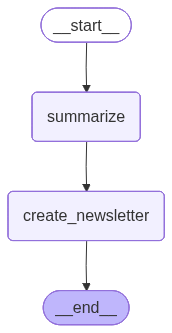

In [16]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(ArticleState)

# 노드 추가
builder.add_node(summarize)
builder.add_node(create_newsletter)

# 엣지 추가 (실행 순서)
builder.add_edge(START, 'summarize')
builder.add_edge('summarize', 'create_newsletter')
builder.add_edge('create_newsletter', END)

# 컴파일
graph = builder.compile()
graph

In [17]:
# 그래프 실행 (LangFuse 트레이싱 포함)
from langchain_community.document_loaders import WebBaseLoader

sample_URL='https://ejholmes.github.io/2026/02/28/mcp-is-dead-long-live-the-cli.html'
loader = WebBaseLoader(web_path=sample_URL)


article = ' '.join(loader.load()[0].page_content.replace('\n\n', '\n').split())

print("원문:", article[0:300], '(중략)...')

result = graph.invoke(
    {'article': article},
    config={'callbacks': callbacks}
)

print('--- 요약 ---')
print(result['summary'])
print('\n\n\n--- 뉴스레터 ---')
print(result['newsletter'])

USER_AGENT environment variable not set, consider setting it to identify your requests.


원문: MCP is dead. Long live the CLI Eric Holmes GitHub Keybase Email MCP is dead. Long live the CLI February 28, 2026 I’m going to make a bold claim: MCP is already dying. We may not fully realize it yet, but the signs are there. OpenClaw doesn’t support it. Pi doesn’t support it. And for good reason. Wh (중략)...
--- 요약 ---
에릭 홀머스는 MCP가 이미 사망했으며 CLI가 그 자리를 대체해야 한다는 주장으로 글을 시작한다. 그는 모든企業が "AI 퍼스트"라는 명분 아래 MCP 서버를 급히 출시하며 막대한 자원을 낭비했다고 비판한다. LLM은 이미 방대한 코드와 매뉴얼을 학습해 복잡한 프로토콜 없이도 명령줄을 효과적으로 사용할 수 있다. MCP가 깔끔한 인터페이스를 약속했음에도, 실제로는 여전히 도구의 기능과 매개변수에 대한 문서화가 필요했다. CLI를 사용하면 동일한 입력과 출력을 확인함으로써 인간과 AI의 작업 결과를 직접 비교할 수 있어 디버깅이 훨씬 수월하다. 반면 MCP는 LLM 내부 컨텍스트에 갇혀 있어 오류 발생 시 JSON 로그 해석이라는 불필요한 복잡성을 초래한다. CLI는 파이프라인과 유틸리티를 연결하여 강력한 조합성을 제공하지만, MCP는 대용량 데이터를 컨텍스트 창에 넣어야 하거나 서버를 커스터마이징해야 하는 비효율적인 대안만 남긴다. 인증 측면에서 MCP는 불필요하게 의견이 강하며, 이미 검증된 AWS나 GitHub의 인증 체계가 CLI에서 완벽하게 작동한다. 또한 MCP 서버는 백그라운드 프로세스를 필요로 하여 시작 오류나 상태 관리 문제를 초래하는 반면, CLI는 실행 파일로써 즉시 활용 가능하다. 실제 사용 중에는 초기화 실패, 반복적인 재인증, 그리고 제한된 권한 제어 등으로 인해 상

### 스트리밍으로 실행 과정 확인

`stream()`을 사용하면 각 노드의 실행 결과를 실시간으로 확인할 수 있습니다.

In [18]:
sample_URL='https://www.philschmid.de/agent-harness-2026'
loader = WebBaseLoader(web_path=sample_URL)
article = ' '.join(loader.load()[0].page_content.replace('\n\n', '\n').split())

print("원문:", article[0:300], '(중략)...')

for step in graph.stream(
    {'article': article},
    config={'callbacks': callbacks}
):
    for node_name, output in step.items():
        print(f'--- {node_name} ---')
        for key, value in output.items():
            print(f'  {key}: {str(value)}')
        print('\n\n\n\n')

원문: The importance of Agent Harness in 2026PhilschmidSearch⌘kBlogProjectsNewsletterAbout MeToggle MenuThe importance of Agent Harness in 2026 January 5, 20266 minute readWe are at a turning point in AI. For years, we focused only on the model. We asked how smart/good the model was. We checked leaderboar (중략)...
--- summarize ---
  summary: 2026년 AI 산업은 단일 모델의 성능 경쟁에서 장기적인 작업 수행의 내구성 경쟁으로 전환되고 있다. 정적 벤치마크에서는 차이를 발견하기 어렵지만, 수백 번의 도구 호출이 필요한 복잡한 장기 작업에서 모델 간 신뢰도 격차가 명확히 드러난다. 에이전트 하니스는 AI 모델을 감싸는 인프라로, 장기 실행 작업을 관리하고 안정성과 효율성을 보장한다. 이는 프레임워크가 구성 요소를 제공하는 것과 달리, 프롬프트 사전 설정 및 라이프사이클 훅 등 완성된 기능을 제공한다. 컴퓨터 시스템에 비유하자면 모델은 CPU, 컨텍스트 윈도우는 RAM, 에이전트 하니스는 운영 체제(OS) 역할을 한다. 하니스는 컴팩션이나 상태 저장 등 컨텍스트 엔지니어링 전략을 구현하여 개발자가 핵심 로직에만 집중하도록 돕는다. 현재 일반적인 하니스는 드물지만, Claude Code와 같은 사례에서 그雏形이 나타나고 있다. 기존 벤치마크는 단일 턴 출력에 집중하여 장기 작업의 내구성을 측정하는 데 한계가 있다. 하니스는 실제 사용 사례에 대한 모델 성능 비교를 가능하게 하여 현실적인 진전을 검증하는 역할을 한다. 또한 표준화된 환경은 사용자 경험을 일관되게 유지하고, 피드백 루프를 통해 시스템 개선을 촉진한다. 리치 서튼의 '쓴 Lesson'에 따라, 경직된 수동 코딩보다는 가벼운 인프라가 계산량을

---
## 3. 조건부 분기 그래프

`add_conditional_edges`를 사용하면 조건에 따라 다른 노드로 분기할 수 있습니다.

분기를 결정하는 분류 노드는 자유 텍스트 대신 `response_format`으로 구조화된 출력을 받습니다.
출력이 tech 또는 general 두 값으로 고정되어, 문자열 파싱 없이 `structured_response`로 안전하게 분기합니다.

In [19]:
from typing import Literal
from pydantic import BaseModel, Field


class RouterState(TypedDict):
    question: str    # 사용자 질문
    category: str    # 분류 결과
    answer: str      # 답변


class QuestionCategory(BaseModel):
    """질문 분류 결과"""
    category: Literal['tech', 'general'] = Field(
        description='기술 관련 질문이면 tech, 그 외 일상/상식 질문이면 general')


classifier = create_agent(
    llm,
    tools=[],
    system_prompt='사용자 질문의 카테고리를 판단합니다.',
    response_format=QuestionCategory,
)

tech_expert = create_agent(
    llm,
    tools=[],
    system_prompt='당신은 기술 전문가입니다. 전문적이고 정확하게 3문장 이내로 답변하세요.',
)

general_expert = create_agent(
    llm,
    tools=[],
    system_prompt='당신은 친근한 상식 전문가입니다. 쉽게 3문장 이내로 설명하세요.',
)


def classify_question(state: RouterState) -> RouterState:
    """질문을 분류하는 노드. structured_response로 분류 결과를 받는다."""
    result = classifier.invoke({'messages': [HumanMessage(state['question'])]})
    return {'category': result['structured_response'].category}


def answer_tech(state: RouterState) -> RouterState:
    """기술 전문가로서 답변하는 노드"""
    result = tech_expert.invoke({'messages': [HumanMessage(state['question'])]})
    return {'answer': result['messages'][-1].text}


def answer_general(state: RouterState) -> RouterState:
    """친근한 상식 전문가로서 답변하는 노드"""
    result = general_expert.invoke({'messages': [HumanMessage(state['question'])]})
    return {'answer': result['messages'][-1].text}


def route_question(state: RouterState) -> str:
    """분류 결과에 따라 분기하는 조건 함수"""
    return state['category']

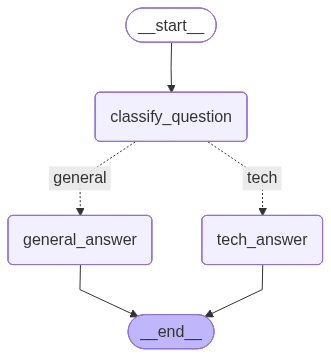

In [21]:
builder2 = StateGraph(RouterState)

builder2.add_node(classify_question)
builder2.add_node('tech_answer', answer_tech)
builder2.add_node('general_answer', answer_general)

builder2.add_edge(START, 'classify_question')

# 조건부 분기: classify_question의 결과에 따라 다른 노드로 이동
builder2.add_conditional_edges(
    'classify_question',    # 시작 노드
    route_question,         # 조건 함수
    {'tech': 'tech_answer', 'general': 'general_answer'}  # 분기 매핑
)

builder2.add_edge('tech_answer', END)
builder2.add_edge('general_answer', END)

graph2 = builder2.compile()
graph2

In [22]:
# 기술 질문
r1 = graph2.invoke(
    {'question': 'LangGraph의 StateGraph는 어떻게 동작하나요?'},
    config={'callbacks': callbacks}
)
print(f'카테고리: {r1["category"]}')
print(f'답변: {r1["answer"]}')

카테고리: tech
답변: StateGraph는 노드(Node) 간 연결을 정의하고 각 노드가 공유하는 상태(State) 사본을 관리하여 데이터 흐름을 추적합니다. 실행 시 조건부 라우팅이나 정적 그래프 구조에 따라 특정 노드로 전환되며, 각 노드는 이전 상태의 사본을 받아 수정하여 다음 노드에 전달합니다. 이렇게 상태 객체가 노드를 거치면서 업데이트되고, 종료 조건에 도달하면 최종 상태 값이 반환됩니다.


In [23]:
# 일반 질문
r2 = graph2.invoke(
    {'question': '커피가 건강에 좋은가요?'},
    config={'callbacks': callbacks}
)
print(f'카테고리: {r2["category"]}')
print(f'답변: {r2["answer"]}')

카테고리: general
답변: 적당한 양의 커피는 항산화 성분 덕분에 간 건강 개선이나 인지 기능 보호에 도움이 될 수 있습니다. 하지만 카페인에 민감하거나 수면 장애가 있다면 피로가 쌓일 수 있으므로 섭취량을 조절하는 것이 좋습니다. 결국 본인의 체질과 하루 섭취량(보통 3~4잔 이내)을 잘 맞추는 것이 가장 중요합니다.


## [실습] 작업 흐름과 에이전트 혼합 구조 설계하기

위 그래프의 구조에서, tech 질문인 경우에만 웹 검색 도구를 연결한 ReAct 에이전트가 대신 답변하게 만들어 보세요.
검색 도구는 tools 모듈의 `web_search`를 사용합니다.

In [25]:
from tools import web_search

# 검색 도구 확인
print(web_search.name)
print(web_search.description)

tavily_search
A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.


In [29]:
# 에이전트 구성
tech_expert = create_agent(
    llm,
    tools=[web_search],
    system_prompt='당신은 기술 전문가입니다. 전문적이고 정확하게 3문장 이내로 답변하세요.',
)
def answer_tech(state: RouterState) -> RouterState:
    """기술 전문가로서 답변하는 노드"""
    result = tech_expert.invoke({'messages': [HumanMessage(state['question'])]})
    return {'answer': result['messages'][-1].text}

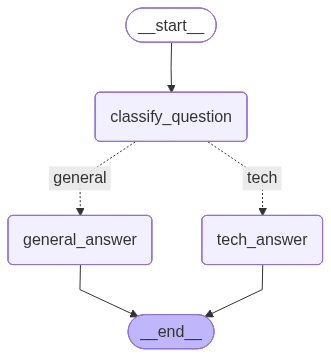

In [30]:
# 웹 검색을 사용하는 답변 노드를 작성하세요
builder2 = StateGraph(RouterState)

builder2.add_node(classify_question)
builder2.add_node('tech_answer', answer_tech)
builder2.add_node('general_answer', answer_general)

builder2.add_edge(START, 'classify_question')

# 조건부 분기: classify_question의 결과에 따라 다른 노드로 이동
builder2.add_conditional_edges(
    'classify_question',    # 시작 노드
    route_question,         # 조건 함수
    {'tech': 'tech_answer', 'general': 'general_answer'}  # 분기 매핑
)

builder2.add_edge('tech_answer', END)
builder2.add_edge('general_answer', END)

graph2 = builder2.compile()
graph2


In [ ]:
# 전체 그래프를 구성하세요




In [ ]:
# 그래프 실행 확인




---
## 4. 상태 리듀서 (Annotated + add_messages)

`Annotated`와 리듀서를 사용하면 상태 값을 처리하는 방식을 지정할 수 있습니다.

- 기본 동작: 반환된 값으로 해당 상태 값을 다시 저장
- `add_messages` 리듀서: 반환된 메시지를 messages 리스트에 누적

In [31]:
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]
    # add_messages 리듀서: 반환된 메시지가 messages 리스트에 누적됨
    # 기존 messages가 있는데 새로운 messages가 return되면
    # add_messages(old, new) 결과를 저장 


llm = load_model(platform=PLATFORM)

def chat(state:ChatState):
    return {'messages': llm.invoke(state['messages'])}


builder3 = StateGraph(ChatState)
builder3.add_node('chatbot', chat)
builder3.add_edge(START, 'chatbot')
builder3.add_edge('chatbot', END)

graph3 = builder3.compile()

result = graph3.invoke(
    {'messages': [HumanMessage('LangGraph란 무엇인가요?')]},
    config={'callbacks': callbacks}
)

# add_messages 덕분에 입력과 응답이 모두 messages에 포함됨
for msg in result['messages']:
    print(f'{type(msg).__name__}: {msg.text}')

HumanMessage: LangGraph란 무엇인가요?
AIMessage: **랭그래프(LangGraph)**는 LangChain 생태계에서 개발된, **다중 에이전트 시스템(Multi-Agent Systems)**과 **복잡한 워크플로우**를 구축하기 위한 라이브러리입니다.

기존의 LangChain이 비교적 단순하고 선형적인 LLM 애플리케이션을 만드는 데 특화되어 있었다면, LangGraph는 **순환(Cyclic) 구조**와 **상태 관리(State Management)**에 중점을 두어 더 정교하고 동적인 AI 애플리케이션을 설계할 수 있게 해줍니다.

### LangGraph의 핵심 개념과 특징

1. **그래프 기반 아키텍처 (Graph-Based Architecture)**
   - LangGraph는 `노드(Node)`와 `에지(Edge)`로 구성된 그래프 구조를 사용합니다.
   - 각 노드는 LLM 호출, 도구 사용(tool use), 조건부 로직 등 하나의 작업을 수행합니다.
   - 에지는 노드들을 연결하여 실행 흐름을 정의합니다.

2. **순환(Cyclic) 흐름 지원**
   - 기존 LangChain의 `Chain`은 대부분 선형적이었습니다(L → B → C).
   - LangGraph는 **루프(Loop)**를 지원합니다. 이는 LLM이 결과를 판단하고, 필요하면 다시 이전 단계로 돌아가 작업을 반복하거나 수정하는 **"Self-Correction"**나 **"Agentic Loop"** 패턴을 구현하는 데 필수적입니다.

3. **상태 관리 (State Management)**
   - 애플리케이션 전체의 상태를 `State`라는 객체로 명시적으로 관리합니다.
   - 각 노드는 이 상태를 읽고, 수정하여 다음 노드에 전달합니다. 이를 통해 복잡한 대화 맥락이나 작업 진행 상태를 추적할 수 있습니다.

4. **인내성(Tolerance)과 재시도 (Persistence & Checkpointing)**
   - 실행 중인 

---
## 정리

이번 실습에서 학습한 내용을 정리합니다.

- StateGraph: 그래프의 뼈대. `TypedDict`로 State를 정의하고 노드/엣지를 추가
- Node: State를 입력받아 새로 쓸 필드를 dict로 반환하는 함수. LLM 호출은 create_agent 에이전트로 처리
- 리턴값 규칙: 분기를 결정하는 노드는 `structured_response`, 텍스트가 산출물인 노드는 마지막 메시지의 `.text`를 State에 저장
- Edge: `add_edge(A, B)`로 노드 간 연결. `START`와 `END`로 시작/종료 지점 설정
- Conditional Edge: `add_conditional_edges(노드, 조건함수, 매핑)`으로 조건 분기
- Annotated 리듀서: `Annotated[list, add_messages]`로 메시지를 덮어쓰기 대신 누적. messages를 공유하면 에이전트를 그래프 노드로 연결할 수 있음
- stream(): 각 노드의 실행 결과를 실시간 확인
- LangFuse: `CallbackHandler`를 `config={'callbacks': [...]}`로 전달하여 모든 그래프 실행을 트레이싱